# Class 12: SQL and Statcast data

Plan for today is to learn the basics of structured query language (SQL) and to gain practice analyzing Statcast data. 


The code below downloads the Lahman baseball dataset, which, as you know, contains data on all Major League Baseball teams from 1871 to 2025. This time we are downloading it as a  as a DuckDB file, which is a type of database that can be queried using SQL. The file contains all the tables in Lahman database in a single file. We will learn how to use SQL to query this database and perform some basic data analysis on the data.


In [166]:
import YData_baseball

YData_baseball.download_data("lahman_2025.duckdb")


# The code below can be used to download a Statcast data file in case it's too slow to query directly from the google drive link. 

def get_statcast_parquet():

    import requests
    import os
    
    data_url = "https://drive.google.com/uc?export=download&id=1sAtrrg4WKzoP7EjQwg2jzH4ufruEX8zS"

    if os.path.exists("statcast_2023.parquet"):
        print("File already exists, skipping download.")
        return

    response = requests.get(data_url)
    with open("statcast_2023.parquet", "wb") as f:
        f.write(response.content)


# get_statcast_parquet()



The file `lahman_2025.duckdb` already exists.
If you would like to download a new copy of the file, please rename the existing copy of the file.


In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Part 1: SQL and the Lahman database

Structured Query Language (SQL) is a programming language used for querying and updating a database. It is a powerful tool for data analysis and is widely used in industry. SQL allows you to perform complex queries on large datasets, and it is often faster than using a programming language like Python or R for data analysis. Today we will learn the basics of SQL and how to use it to query the Lahman database.


## 1.1 Connecting to a database

As a first step we need to connect to the database. This is done using a database management system (DBMS), which is software that allows us to interact with the database. There are many different DBMSs available, but for this class we will be using [DuckDB](https://duckdb.org/), which is a lightweight, in-process SQL database. DuckDB is easy to use and does not require any setup or configuration, making it ideal for our purposes.

The code below imports the DuckDB library. Let's use the `connect()` function to connect to the `lahman_2025.duckdb` database file that we downloaded. The `connect()` function returns a connection object that we can use to execute SQL queries on the database. We will use this connection object throughout the next set of exercises query the database and perform data analysis.


In [168]:
import duckdb

con = duckdb.connect("lahman_2025.duckdb")

con

## 1.2 Seeing the tables in the database

Now that we've connected to the database, let's see what tables are in the database using the `SHOW TABLES` command. 

To execute a command in SQL, we can use the `execute()` method of the connection object. This method takes a string containing the SQL command as an argument and executes it on the database. The `SHOW TABLES` command will return a list of all the tables in the database. We can also use the `DESCRIBE` command to see the structure of a specific table, including the names and data types of the columns in the table.

Also, once we have executed a command, we can use the `fetchall()` method to retrieve the results of the command as a list of tuples, or we can use the `fetchdf()` method to retrieve the results as a pandas DataFrame. This allows us to easily manipulate and analyze the data using Python after retrieving it from the database.


In [169]:
# Use the fetchall() method to return a list of tuples of the tables in the database

con.execute("SHOW TABLES").fetchall()


[('AllstarFull',),
 ('Appearances',),
 ('AwardsManagers',),
 ('AwardsPlayers',),
 ('AwardsShareManagers',),
 ('AwardsSharePlayers',),
 ('Batting',),
 ('BattingPost',),
 ('CollegePlaying',),
 ('Fielding',),
 ('FieldingOF',),
 ('FieldingOFsplit',),
 ('FieldingPost',),
 ('HallOfFame',),
 ('HomeGames',),
 ('Managers',),
 ('ManagersHalf',),
 ('Parks',),
 ('People',),
 ('Pitching',),
 ('PitchingPost',),
 ('Salaries',),
 ('Schools',),
 ('SeriesPost',),
 ('Teams',),
 ('TeamsFranchises',),
 ('TeamsHalf',)]

In [170]:
# Use the fetchdf() method to return a pandas DataFrame of the tables in the database

df = con.execute("SHOW TABLES").fetchdf()
df.head(7)

,name
0,AllstarFull
1,Appearances
2,AwardsManagers
3,AwardsPlayers
4,AwardsShareManagers
5,AwardsSharePlayers
6,Batting


In [171]:
# Use the DESCRIBE command to see the structure of the Batting table 
# This will show us the names and data types of the columns in the Batting table

con.execute("DESCRIBE Batting").fetchdf()


,column_name,column_type,null,key,default,extra
0,playerID,VARCHAR,YES,None,None,None
1,yearID,BIGINT,YES,None,None,None
2,stint,BIGINT,YES,None,None,None
3,teamID,VARCHAR,YES,None,None,None
4,lgID,VARCHAR,YES,None,None,None
5,G,BIGINT,YES,None,None,None
6,AB,BIGINT,YES,None,None,None
7,R,BIGINT,YES,None,None,None
8,H,BIGINT,YES,None,None,None
9,2B,BIGINT,YES,None,None,None


## 1.3 SELECT statements

All SQL queries must start with a `SELECT` statement. It is used to select columns (or functions of columns) from a database and return it as a result set. 

The `SELECT` statement must always be followed by a `FROM` clause, which specifies the table from which to select the data. 

Let's try selecting columns from the `Batting` table!



In [172]:
# Select the playerID, yearID, teamID, and HR columns from the Batting table

my_query = "SELECT playerID, yearID, teamID, HR FROM Batting;"
con.execute(my_query).fetchdf().head()

,playerID,yearID,teamID,HR
0,aardsda01,2004,SFN,0
1,aardsda01,2006,CHN,0
2,aardsda01,2007,CHA,0
3,aardsda01,2008,BOS,0
4,aardsda01,2009,SEA,0


In [173]:
# Get the full table (i.e, all columns)

my_query = "SELECT * FROM Batting;"
con.execute(my_query).fetchdf().head()

,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,...,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
0,aardsda01,2004,1,SFN,NL,11,0,0,0,0,...,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,aardsda01,2006,1,CHN,NL,45,2,0,0,0,...,0.0,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0,0.0
2,aardsda01,2007,1,CHA,AL,25,0,0,0,0,...,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,aardsda01,2008,1,BOS,AL,47,1,0,0,0,...,0.0,0.0,0.0,0,1.0,0.0,0.0,0.0,0.0,0.0
4,aardsda01,2009,1,SEA,AL,73,0,0,0,0,...,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [174]:
# Select functions of columns and store under a new name using the AS keyword

my_query = "SELECT playerID, yearID, H/AB AS avg FROM Batting;"
con.execute(my_query).fetchdf()

,playerID,yearID,avg
0,aardsda01,2004,NaN
1,aardsda01,2006,0.000000
2,aardsda01,2007,NaN
3,aardsda01,2008,0.000000
4,aardsda01,2009,NaN
...,...,...,...
128593,zwilldu01,1915,0.286496
128594,zwilldu01,1916,0.113208
128595,zychto01,2015,NaN
128596,zychto01,2016,NaN


In [175]:
# Using the concat function to combine the first and last name of players in the People table

my_query = "SELECT playerID, concat(nameFirst, ' ', nameLast) AS full_name FROM People;"
con.execute(my_query).fetchdf().head()


,playerID,full_name
0,aardsda01,David Aardsma
1,aaronha01,Hank Aaron
2,aaronto01,Tommie Aaron
3,aasedo01,Don Aase
4,abadan01,Andy Abad


In [176]:
# Using arithmetic operations to calculate the number of singles for each player in the Batting table. 
# Note: because the 2B and 3B columns start with numbers, we need to put these columns in quotes

my_query = 'SELECT playerID, yearID, H-"2B"-"3B"-HR AS singles FROM Batting;'
con.execute(my_query).fetchdf()

,playerID,yearID,singles
0,aardsda01,2004,0
1,aardsda01,2006,0
2,aardsda01,2007,0
3,aardsda01,2008,0
4,aardsda01,2009,0
...,...,...,...
128593,zwilldu01,1915,105
128594,zwilldu01,1916,4
128595,zychto01,2015,0
128596,zychto01,2016,0


#### Exercise

Calculate the ratio of total number of hits (`H`) to the total number of strike outs (`SO`) for all batters who ever played.  This will give us a measure of how many hits have occurred for every strike out. Please save this as a new column with the name `H_per_SO`.


In [177]:
# Get the ratio of total number of hits (H) to the total number of strike outs (SO) for all batters who ever played.  
# Please save this as a new column with the name "H_per_SO".

my_query = 'SELECT sum(H)/sum(SO) AS H_per_SO FROM Batting;'
con.execute(my_query).fetchdf()

,H_per_SO
0,1.798817


## 1.4 WHERE clause

The `WHERE` clause is used to filter the results of a query based on a specified condition (i.e., allows us to select only the rows that meet certain criteria). The condition can be based on the values of one or more columns in the table, and it can use various comparison operators such as `=`, `<`, `>`, `<=`, `>=`, and `!=` . We can also use logical operators such as `AND`, `OR`, and `NOT` to combine multiple conditions. 

The `WHERE` clause is typically used after the `FROM` clause in a `SELECT` statement to filter the results before they are returned.


In [178]:
# Get the playerID, yearID, teamID, and HR columns from the Batting table for all players who hit at least 60 home runs in a season.

my_query = """
SELECT playerID, yearID, teamID, HR 
FROM Batting 
WHERE HR >= 60;
"""

con.execute(my_query).fetchdf()


,playerID,yearID,teamID,HR
0,bondsba01,2001,SFN,73
1,judgeaa01,2022,NYA,62
2,marisro01,1961,NYA,61
3,mcgwima01,1998,SLN,70
4,mcgwima01,1999,SLN,65
5,raleica01,2025,SEA,60
6,ruthba01,1927,NYA,60
7,sosasa01,1998,CHN,66
8,sosasa01,1999,CHN,63
9,sosasa01,2001,CHN,64


In [179]:
# Get the playerID, yearID, and batting average (as avg) for all players who had an avg over 300 

my_query = """
SELECT playerID, yearID, H/AB AS avg 
FROM Batting 
WHERE avg > .300;"""

con.execute(my_query).fetchdf()


my_query = "SELECT playerID, yearID, H/AB AS avg FROM Batting WHERE avg != 'NaN' AND avg > .300 AND AB > 300;"
con.execute(my_query).fetchdf()


,playerID,yearID,avg
0,aaronha01,1955,0.313953
1,aaronha01,1956,0.328407
2,aaronha01,1957,0.321951
3,aaronha01,1958,0.326123
4,aaronha01,1959,0.354531
...,...,...,...
4665,ziskri01,1973,0.324324
4666,ziskri01,1974,0.313433
4667,ziskri01,1981,0.310924
4668,zobribe01,2018,0.305495


In [180]:
# Get the playerID, yearID, and batting average (as avg) for all players who had an avg over 300 between 2010 and 2020 


my_query = """
SELECT playerID, yearID, H/AB AS avg 
FROM Batting 
WHERE avg != 'NaN' AND avg > .300 AND AB > 300 
AND yearID BETWEEN 2010 AND 2020;
"""

con.execute(my_query).fetchdf()


,playerID,yearID,avg
0,abreujo02,2014,0.316547
1,abreujo02,2017,0.304348
2,alberha01,2019,0.305344
3,altuvjo01,2014,0.340909
4,altuvjo01,2015,0.313480
...,...,...,...
279,youklke01,2010,0.306630
280,youngmi02,2011,0.337559
281,zimmery01,2010,0.306667
282,zimmery01,2017,0.303435


In [181]:
# Get the playerID, yearID, and batting average (as avg) for all players who had an avg over 300 from the red sox and yankees 


my_query = """
SELECT playerID, yearID, teamID, H/AB AS avg 
FROM Batting 
WHERE avg != 'NaN' AND avg > .300 
AND teamID IN ('BOS', 'NYA');
"""

con.execute(my_query).fetchdf()


,playerID,yearID,teamID,avg
0,abreubo01,2006,NYA,0.330144
1,abreuwi02,2023,BOS,0.315789
2,adamsbo01,1925,BOS,0.333333
3,agganha01,1955,BOS,0.313253
4,alexada01,1932,BOS,0.372340
...,...,...,...,...
1084,youklke01,2010,BOS,0.306630
1085,youngcy01,1903,BOS,0.321168
1086,zalusja01,1903,NYA,0.312500
1087,zarilal01,1950,BOS,0.324841


#### Exercise

Please return the `playerID`, `yearID`, `teamID`, `HR`, and `SB` columns from the `Batting` table for all players who hit at least 40 home runs and stole at least 40 bases in a season.



In [182]:
# Get the playerID, yearID, teamID, and HR columns from the Batting table for all players who hit at least 40 home runs and stole at least 40 bases in a season.

my_query = """
SELECT playerID, yearID, HR, SB 
FROM Batting 
WHERE HR >= 40 AND SB >= 40;"""

con.execute(my_query).fetchdf()



,playerID,yearID,HR,SB
0,acunaro01,2023,41,73.0
1,bondsba01,1996,42,40.0
2,cansejo01,1988,42,40.0
3,ohtansh01,2024,54,59.0
4,rodrial01,1998,42,46.0
5,soriaal01,2006,46,41.0


## 1.5 GROUP BY clause

The `GROUP BY` clause is used to group the results of a query based on the values of one or more columns. It allows us to perform aggregate functions such as `SUM`, `COUNT`, `AVG`, `MAX`, and `MIN` on the grouped data. 

When using `GROUP BY`, we can only select columns that are either included in the `GROUP BY` clause or are used in an aggregate function. This is because the `GROUP BY` clause groups the data based on the specified columns, and any columns that are not included in the `GROUP BY` clause cannot be selected without being aggregated.


In [183]:
# Get the total number of home runs hit for each team since 1950 

my_query = """
SELECT teamID, sum(HR) 
FROM Batting 
WHERE yearID >= 1950 
GROUP BY teamID;
"""

con.execute(my_query).fetchdf().head()


,teamID,sum(HR)
0,TOR,8407.0
1,ATL,9541.0
2,FLO,2816.0
3,WS1,1064.0
4,SFN,9935.0


In [184]:
# Get the average number of home runs hit per season for each team since 1950

my_query = """
SELECT teamID, sum(HR)/count(*) as hrRate 
FROM Teams 
WHERE yearID >= 1950 
GROUP BY teamID;
"""

con.execute(my_query).fetchdf().head()

,teamID,hrRate
0,PHI,140.078947
1,SE1,125.000000
2,MON,121.694444
3,ML4,130.857143
4,NYA,173.421053


In [185]:
# Get the average number of home runs hit per season for each league since 2000

my_query = """
SELECT yearID, lgID, sum(HR)/count(*) as hrRate 
FROM Teams 
WHERE yearID >= 2000 
GROUP BY yearID, lgID;
"""

con.execute(my_query).fetchdf().head()

,yearID,lgID,hrRate
0,2007,NL,169.062500
1,2004,NL,177.875000
2,2011,AL,162.214286
3,2016,NL,177.133333
4,2018,NL,179.000000


#### Exercise

Get the total number of years each baseball team has played in each year since 1950 

Hint: using `count(*)` could be useful here.


In [186]:
# Get the total number of years each team has played in each year since 1950 

my_query = """
SELECT teamID, count(*) as yearsPlayed 
FROM Teams 
WHERE yearID >= 1970 
GROUP BY teamID;
"""

con.execute(my_query).fetchdf().head()

,teamID,yearsPlayed
0,KCA,56
1,NYA,56
2,TOR,49
3,CHN,56
4,TBA,28


## 1.6 ORDER BY

The `ORDER BY` clause is used to sort the results of a query based on the values of one or more columns. It allows us to specify the sort order (ascending or descending) for each column. By default, the sort order is ascending, but we can use the `DESC` keyword to specify descending order. 

In [187]:
# Get the total number of home runs hit by each team since 1950, sorted in descending order by the number of home runs

my_query = """
SELECT yearID, teamID, HR 
FROM Teams 
ORDER BY HR desc;
"""

con.execute(my_query).fetchdf().head()

,yearID,teamID,HR
0,2019,MIN,307.0
1,2023,ATL,307.0
2,2019,NYA,306.0
3,2019,HOU,288.0
4,2019,LAN,279.0


# Exercise

Since 1950, what is the average number of strike outs per game for each year? Which year had the highest average number of strike outs per game?

Hint: the `SO` column could be useful

In [188]:
# Exercise: Since 1950, what is the average number of strike outs per game for each year? 
# Which year had the highest average number of strike outs per game?

my_query = """
SELECT yearID, sum(SO)/sum(G) as SO_avg 
FROM Teams 
WHERE yearID > 1950 
GROUP BY yearID 
ORDER BY SO_avg desc;
"""

con.execute(my_query).fetchdf().head()

,yearID,SO_avg
0,2019,8.814944
1,2020,8.678174
2,2021,8.675381
3,2023,8.609671
4,2024,8.480239


In [189]:
# Can also look at the number of home runs per game for each year

my_query = """
SELECT yearID, sum(HR)/sum(G) as HR_avg 
FROM Teams 
GROUP BY yearID 
ORDER BY HR_avg desc;
"""

con.execute(my_query).fetchdf().head()

,yearID,HR_avg
0,2019,1.394813
1,2020,1.282851
2,2017,1.256173
3,2021,1.223549
4,2023,1.207407


## 1.7 LIMIT and SAMPLE

The `LIMIT` clause is used to specify the maximum number of rows that should be returned by a query. It allows us to limit the number of results that are returned, which can be useful when working with large datasets. We can also limit the results to a percentage of the total number of rows. 

We can use the `SAMPLE` keyword to return a random sample of rows from the result set. This can be useful for getting a quick overview of the data without having to retrieve the entire dataset. The `SAMPLE` keyword can be used with either a percentage or a specific number of rows.


In [190]:
# Get the average number of home runs hit per game for each year since 1950, but only return the top 5 years with the highest average number of home runs per season.

my_query = """
SELECT yearID, sum(HR)/sum(G) as HR_avg 
FROM Teams 
GROUP BY yearID 
ORDER BY HR_avg DESC LIMIT 5;"""

con.execute(my_query).fetchdf()

,yearID,HR_avg
0,2019,1.394813
1,2020,1.282851
2,2017,1.256173
3,2021,1.223549
4,2023,1.207407


In [191]:
# Get the average number of home runs hit per game for each year since 1950, but only return the top 5% of years with the highest average number of home runs per season.

my_query = """
SELECT yearID, sum(HR)/sum(G) as HR_avg 
FROM Teams 
GROUP BY yearID 
ORDER BY HR_avg desc 
LIMIT 5%;
"""

con.execute(my_query).fetchdf()

,yearID,HR_avg
0,2019,1.394813
1,2020,1.282851
2,2017,1.256173
3,2021,1.223549
4,2023,1.207407
5,2000,1.171881
6,2025,1.162551


In [192]:
# Get the average number of home runs hit per game but only return a random sample of 10 of the years.

my_query = """
SELECT yearID, sum(HR)/sum(G) as HR_avg 
FROM Teams 
GROUP BY yearID 
USING SAMPLE 10 ROWS;"""

con.execute(my_query).fetchdf()

,yearID,HR_avg
0,1889,0.143885
1,1925,0.750000
2,1926,0.282895
3,1944,0.361290
4,1945,0.611842
5,1961,0.846626
6,1979,1.138365
7,1985,0.956790
8,2020,0.966667
9,2024,1.086420


## 1.8  HAVING

The `HAVING` clause is used to filter the results of a query based on the values that were calculated after the aggregate functions have been run (i.e., after the `GROUP BY` has been applied). This allows us to specify conditions on the grouped data after it has been aggregated. The `HAVING` clause is typically used in conjunction with the `GROUP BY` clause to filter the results of a query based on the values of the grouped data. 



In [193]:
# What is the average batting average for each team, but only include teams that have played at least 20 seasons

my_query = """
SELECT name, min(yearID) as firstSeason, sum(H)/sum(AB) AS avg, count(*) AS num_seasons
FROM Teams
GROUP BY name
HAVING num_seasons >= 20
ORDER BY avg DESC
LIMIT 8;
"""
con.execute(my_query).fetchdf()


,name,firstSeason,avg,num_seasons
0,New York Lincoln Giants,1911,0.303476,20
1,Homestead Grays,1928,0.290533,21
2,Kansas City Monarchs,1920,0.284280,29
3,New York Giants,1885,0.271669,74
4,Colorado Rockies,1993,0.269606,33
5,Brooklyn Dodgers,1911,0.267628,28
6,Boston Red Sox,1908,0.267507,118
7,Boston Beaneaters,1883,0.267279,24


## 1.9 JOIN

The `JOIN` clause is used to combine rows from two or more tables based on a related column between them. It allows us to retrieve data from multiple tables in a single query. 

There are several types of JOINs, including `INNER JOIN`, `LEFT JOIN`, `RIGHT JOIN`, and `FULL OUTER JOIN`, each of which specifies how the rows from the tables should be combined based on the related columns. The `JOIN` clause is typically used in conjunction with the `ON` keyword to specify the condition for joining the tables.



In [194]:
# Join the Batting and People tables to get the first and last name of all players who hit at least 60 home runs in a season. 

my_query = """
SELECT nameFirst, nameLast, HR 
FROM Batting 
LEFT JOIN People ON People.playerID = Batting.playerID
WHERE HR >= 60
"""
con.execute(my_query).fetchdf()


,nameFirst,nameLast,HR
0,Barry,Bonds,73
1,Aaron,Judge,62
2,Roger,Maris,61
3,Mark,McGwire,65
4,Mark,McGwire,70
5,Cal,Raleigh,60
6,Babe,Ruth,60
7,Sammy,Sosa,64
8,Sammy,Sosa,63
9,Sammy,Sosa,66


In [195]:
# Same query as above with aliases

my_query = """
SELECT  p.nameFirst, 
        p.nameLast, 
        b.yearID, 
        b.HR 
FROM Batting b
LEFT JOIN People p ON b.playerID = p.playerID
WHERE b.HR >= 60
"""

con.execute(my_query).fetchdf()


,nameFirst,nameLast,yearID,HR
0,Barry,Bonds,2001,73
1,Aaron,Judge,2022,62
2,Roger,Maris,1961,61
3,Mark,McGwire,1999,65
4,Mark,McGwire,1998,70
5,Cal,Raleigh,2025,60
6,Babe,Ruth,1927,60
7,Sammy,Sosa,2001,64
8,Sammy,Sosa,1999,63
9,Sammy,Sosa,1998,66


#### Exercise 

Get a list of all major league pitchers who played college baseball at Yale, along with the first and last year they played in college, the total number of strike outs they had in their MLB career, and the first and last year they played in the MLB.

Hint: the `CollegePlaying` and `Pitching` tables will be useful here, and you will need to use JOINs to combine the data from these tables with the `People` table to get the player names. You will also need to use aggregate functions and `GROUP BY` to calculate the total number of strike outs for each player.


In [196]:

my_query = """SELECT 
    p.nameFirst, 
    p.nameLast, 
    MIN(c.yearID) as collge_first_year, 
    MAX(c.yearID) as college_last_year, 
    SUM(s.SO) as total_SO, 
    MIN(s.yearID) as mlb_first_year, 
    MAX(s.yearID) as mlb_last_year 
FROM People p 
INNER JOIN CollegePlaying c ON p.playerID = c.playerID 
INNER JOIN Pitching s ON p.playerID = s.playerID 
WHERE c.schoolID = 'yale' 
GROUP BY 
    p.playerID, 
    p.nameFirst, 
    p.nameLast;
"""


# get as a pandas DataFrame
df = con.execute(my_query).fetchdf()
df

,nameFirst,nameLast,collge_first_year,college_last_year,total_SO,mlb_first_year,mlb_last_year
0,Frank,Quinn,1945.0,1948.0,16.0,1949,1950
1,Bill,Hutchison,1878.0,1881.0,4940.0,1884,1897
2,Jack,Jones,1882.0,1883.0,122.0,1883,1883
3,Ken,MacKenzie,1955.0,1956.0,284.0,1960,1965
4,Craig,Breslow,1999.0,2002.0,1768.0,2005,2017
5,George,Knight,1875.0,1875.0,0.0,1875,1875
6,Joe,Wood,1939.0,1941.0,15.0,1944,1944
7,Ron,Darling,1979.0,1981.0,4770.0,1983,1995
8,Dick,Manville,1945.0,1945.0,8.0,1950,1952
9,Johnny,Broaca,1932.0,1932.0,258.0,1934,1939



Another way to write the same query


In [197]:
df = con.execute("""
WITH pitching_summary AS (
    SELECT 
        playerID,
        SUM(SO) AS total_SO,
        MIN(yearID) AS min_pitch_year,
        MAX(yearID) AS max_pitch_year
    FROM Pitching
    GROUP BY playerID
),
college_summary AS (
    SELECT 
        playerID,
        MIN(yearID) AS min_college_year,
        MAX(yearID) AS max_college_year
    FROM CollegePlaying
    WHERE schoolID = 'yale'
    GROUP BY playerID
)
SELECT 
    p.playerID,
    p.nameFirst,
    p.nameLast,
    c.min_college_year,
    c.max_college_year,
    s.total_SO,
    s.min_pitch_year,
    s.max_pitch_year
FROM People p
JOIN college_summary c 
    ON p.playerID = c.playerID
JOIN pitching_summary s 
    ON p.playerID = s.playerID
""").fetchdf()

df

,playerID,nameFirst,nameLast,min_college_year,max_college_year,total_SO,min_pitch_year,max_pitch_year
0,breslcr01,Craig,Breslow,1999.0,2002.0,442.0,2005,2017
1,broacjo01,Johnny,Broaca,1932.0,1932.0,258.0,1934,1939
2,darliro01,Ron,Darling,1979.0,1981.0,1590.0,1983,1995
3,davisbo01,Bob,Davis,1953.0,1955.0,50.0,1958,1960
4,hutchbi01,Bill,Hutchison,1878.0,1881.0,1235.0,1884,1897
5,jonesja02,Jack,Jones,1882.0,1883.0,61.0,1883,1883
6,knighge01,George,Knight,1875.0,1875.0,0.0,1875,1875
7,mackeke01,Ken,MacKenzie,1955.0,1956.0,142.0,1960,1965
8,manvidi01,Dick,Manville,1945.0,1945.0,8.0,1950,1952
9,pumpesp01,Spencer,Pumpelly,1915.0,1915.0,0.0,1925,1925


## 1.10 UNION

The `UNION` operator is used to combine the results of two or more `SELECT` statements into a single result set. It allows us to retrieve data from multiple tables or queries and combine it into a single result set. The `UNION` operator removes duplicate rows from the result set, so only unique rows will be returned.

The `SELECT` statements that are combined using `UNION` must have the same number of columns and the same data types in each column. The `UNION` operator is typically used to combine the results of multiple queries that return similar data, such as combining the results of two different tables that contain information about players.


In [198]:
# Get all pitchers and batters who played college baseball at Yale, along with the first and last year they played in college, 
#  the total number of games they played in their MLB careers, and the first and last year they played in the MLB.

my_query = """
(SELECT 
    p.nameFirst, 
    p.nameLast, 
    SUM(s.G) as total_games, 
    MIN(c.yearID) as collge_first_year, 
    MAX(c.yearID) as college_last_year, 
    MIN(s.yearID) as mlb_first_year, 
    MAX(s.yearID) as mlb_last_year 
FROM People p 
INNER JOIN CollegePlaying c ON p.playerID = c.playerID 
INNER JOIN Pitching s ON p.playerID = s.playerID 
WHERE c.schoolID = 'yale' 
GROUP BY 
    p.playerID, 
    p.nameFirst, 
    p.nameLast)
UNION
(SELECT 
    p.nameFirst, 
    p.nameLast,
    SUM(s.G) as total_games, 
    MIN(c.yearID) as collge_first_year, 
    MAX(c.yearID) as college_last_year, 
    MIN(s.yearID) as mlb_first_year, 
    MAX(s.yearID) as mlb_last_year 
FROM People p 
INNER JOIN CollegePlaying c ON p.playerID = c.playerID 
INNER JOIN Batting s ON p.playerID = s.playerID 
WHERE c.schoolID = 'yale' 
GROUP BY 
    p.playerID, 
    p.nameFirst, 
    p.nameLast)
ORDER BY mlb_last_year
"""

con.execute(my_query).fetchdf()


,nameFirst,nameLast,total_games,collge_first_year,college_last_year,mlb_first_year,mlb_last_year
0,Al,Nevin,52.0,1871.0,1874.0,1873,1873
1,George,Knight,1.0,1875.0,1875.0,1875,1875
2,Edgar,Smith,30.0,1882.0,1882.0,1883,1883
3,Al,Hubbard,4.0,1882.0,1883.0,1883,1883
4,Sam,Childs,1.0,1883.0,1883.0,1883,1883
5,Jack,Jones,38.0,1882.0,1883.0,1883,1883
6,Bill,Vinton,37.0,1886.0,1886.0,1884,1885
7,Bill,Hutchison,1536.0,1878.0,1881.0,1884,1897
8,Yale,Murphy,524.0,1890.0,1893.0,1894,1897
9,Bill,Hutchison,1504.0,1878.0,1881.0,1884,1897


## 1.11 Closing the connection

Since we are done querying the database we should close the connection to the database to free up resources. This is done using the `close()` method of the connection object. It is important to close the connection when we are done with it to prevent any potential issues with the database and to ensure that resources are properly released.


In [199]:

con.close()


# Part 2: Statcast data with SQL

We can also use SQL and DuckDB to query the Statcast data. This will be particularly useful for looking at all of the Statcast data from a whole season (or more) where downloading this data using the pybaseball package might be difficult. 


## 2.1 Connecting to the DuckDB database

To use DuckDB to query the Statcast data, I compiled the Statcast data for the 2023 season into a DuckDB database file and uploaded it to Google Drive. We can use DuckDB's httpfs extension to read the data directly from the Google Drive link without having to download the data first. This allows us to run SQL queries on the Statcast data without having to load the entire dataset into memory, which can be very useful when working with large datasets.

Note: Since we are not downloading the data, the queries might be a bit slower than if we had the data stored locally. If this turns out to be too slow, you can download the whole DuckDB file (which is a little less than 100 MB) and then query this file locally which will be faster. The function `get_statcast_parquet()`, defined at the top of this Jupyter notebook, will download this file. You can the set the data_url to be `data_url = "statcast_2023.parquet"` to query the data from the local file instead of the google drive link.

In [200]:

import duckdb

conn = duckdb.connect()

# Install and load the httpfs extension (only needs to be run once per session)
conn.execute("INSTALL httpfs;")
conn.execute("LOAD httpfs;")

data_url = "https://drive.google.com/uc?export=download&id=1sAtrrg4WKzoP7EjQwg2jzH4ufruEX8zS"
#data_url = "statcast_2023.parquet"

my_query = f"SELECT * FROM read_parquet('{data_url}') LIMIT 10;"

results = conn.execute(my_query).fetchdf()

results 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches,year
0,FF,2023-03-30,96.3,-2.06,6.03,"Vosler, Jason",613564.0,656605.0,triple,hit_into_play,...,1.07,0.78,-0.78,38.8,NaN,NaN,NaN,NaN,NaN,2023.0
1,FF,2023-03-30,96.7,-2.02,5.94,"Vosler, Jason",613564.0,656605.0,None,foul,...,1.11,0.75,-0.75,39.9,NaN,NaN,NaN,NaN,NaN,2023.0
2,CU,2023-03-30,77.5,-1.80,6.24,"Vosler, Jason",613564.0,656605.0,None,foul_tip,...,5.07,-0.92,0.92,49.1,NaN,NaN,NaN,NaN,NaN,2023.0
3,FF,2023-03-30,97.1,-2.10,5.91,"Stephenson, Tyler",663886.0,656605.0,strikeout,called_strike,...,1.21,0.77,0.77,34.6,NaN,NaN,NaN,NaN,NaN,2023.0
4,SI,2023-03-30,94.1,-2.08,5.99,"Stephenson, Tyler",663886.0,656605.0,None,foul,...,1.85,1.50,1.50,39.4,NaN,NaN,NaN,NaN,NaN,2023.0
5,FF,2023-03-30,96.8,-2.16,6.04,"McNeil, Jeff",643446.0,645261.0,single,hit_into_play,...,1.34,0.93,-0.93,33.5,NaN,NaN,NaN,NaN,NaN,2023.0
6,FF,2023-03-30,98.0,-1.90,5.79,"Pederson, Joc",592626.0,543037.0,strikeout,swinging_strike,...,0.99,0.91,-0.91,39.7,NaN,NaN,NaN,NaN,NaN,2023.0
7,SI,2023-03-30,93.7,-2.08,5.98,"Stephenson, Tyler",663886.0,656605.0,None,called_strike,...,1.78,1.61,1.61,39.8,NaN,NaN,NaN,NaN,NaN,2023.0
8,FF,2023-03-30,96.2,-2.03,6.08,"McNeil, Jeff",643446.0,645261.0,None,ball,...,1.42,0.98,-0.98,37.5,NaN,NaN,NaN,NaN,NaN,2023.0
9,FC,2023-03-30,90.4,-1.93,6.14,"Stephenson, Tyler",663886.0,656605.0,None,ball,...,1.99,-0.01,-0.01,45.0,NaN,NaN,NaN,NaN,NaN,2023.0


## 2.2 Spray charts

Spray charts show the location of batted balls for a particular player. The location where each batted ball was hit is listed in the Statcast data as `hc_x` and `hc_y`, which represent the horizontal and vertical location of the batted ball, respectively. However, these coordinates are not relative to home plate, so we need to adjust them to get the distance from home plate. The adjusted coordinates can be calculated as follows: `horizontal_distance = hc_x - 125.42` and `vertical_distance = 198.27 - hc_y`. These adjusted coordinates will give us the distance of the batted ball from home plate in feet, which we can then use to create a spray chart.

**Exercise**

Please create a spray chart for Shohei Ohtani for the 2023 season using the Statcast data. To do this you will need to write a SQL query selects the following columns: 

1. The adjusted horizontal and vertical distance of batted balls (as described above)
2. The `events` column that lists whether an event was a single, double, triple, field_out, etc.
3. The `pitcher` and `batter` columns to make sure we are only looking at batted balls where Shohei Ohtani was the batter (and not the pitcher)

Make sure this data is only for Shohei Ohtani (`player_name = 'Ohtani, Shohei'`) and save this to a DataFrame called `player_data`. 

Once you have the data in a DataFrame, created a DataFrame called `player_events` that only have the events that are in the following list: `events_to_keep = ['single', 'double', 'triple', 'home_run', 'field_out']`. Then use seaborn to create a scatter plot of the horizontal and vertical distance of batted balls, with the color of the points representing the type of event (e.g., single, double, triple, home run, etc.). You can also move the legend outside of the plot to make it easier to read. 

Note: the `pybaseball` package also has a nice function called `spray_chart()` that can be used to create spray charts. 


In [201]:
%%time


player_name = "Ohtani, Shohei"


my_query = f"""
SELECT hc_x - 125.42 AS horizontal_distance, 
       198.27 - hc_y AS vertical_distance, 
       events, 
       pitcher, 
       batter
FROM read_parquet('{data_url}')
WHERE player_name = '{player_name}' 
"""

player_data = conn.execute(my_query).fetchdf()
player_data.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CPU times: total: 15 s
Wall time: 19.6 s


,horizontal_distance,vertical_distance,events,pitcher,batter
0,41.0,91.87,single,666205.0,660271.0
1,NaN,NaN,None,666205.0,660271.0
2,NaN,NaN,strikeout,666205.0,660271.0
3,NaN,NaN,None,666205.0,660271.0
4,NaN,NaN,None,666205.0,660271.0


In [202]:
# sanity check that it's only when is the batter (and not the pitcher)
print(len(player_data.batter.value_counts()))

# how many unique pitchers he faced
print(len(player_data.pitcher.value_counts()))

1
268


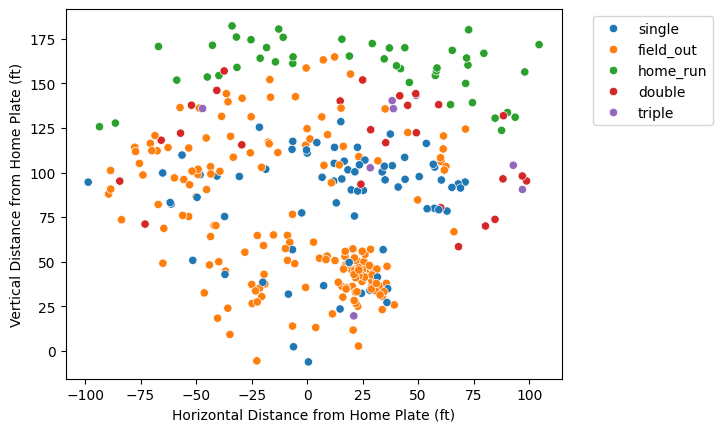

In [203]:
# only use a subset of the events to make the plot easier to read
events_to_keep = [
    'single',
    'double',
    'triple',
    'home_run', 
    #'grounded_into_double_play',
    #'sac_fly',
    'field_out'   # most common "out" event
]


# Filter the dataset
player_events = player_data[player_data['events'].isin(events_to_keep)]


# Visualize the dataset
sns.scatterplot(x=player_events.horizontal_distance, y= player_events.vertical_distance, hue=player_events.events);

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');   # move the legend outside the plot\
plt.xlabel("Horizontal Distance from Home Plate (ft)");
plt.ylabel("Vertical Distance from Home Plate (ft)");
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');


## 2.3 Strike out rates for different pitch types

Let's now calculate the strike out rate for each pitch type, but only include pitch types that were thrown at least 1000 times in the data. 

To do this, use the `SUM` function in conjunction with a `CASE WHEN` statement as: `SUM(CASE WHEN events = 'strikeout' THEN 1 ELSE 0 END) AS strikeouts`. The `CASE WHEN` statement will return 1 for every row where the events column is equal to 'strikeout' and 0 for every other row. Then, by summing this column (and grouping by `pitch_type`), we can get the total number of strike outs for each pitch type. We can also use the `COUNT(*)` function to get the total number of pitches for each pitch type. Finally, we can calculate the strike out rate by dividing the total number of strike outs by the total number of pitches for each pitch type.

**Exercise**

Write a query in SQL as described above and execute it using DuckDB to get the results as a pandas DataFrame. Then use seaborn to create a bar plot of the strike out rate for each pitch type.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

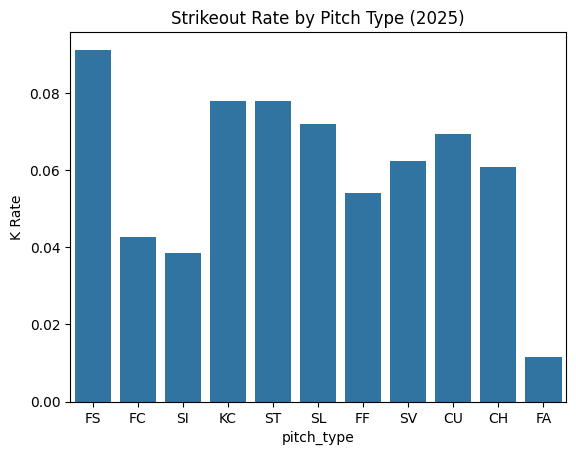

In [204]:

my_query = f"""
SELECT 
    pitch_type,
    COUNT(*) AS total_pitches,
    SUM(CASE WHEN events = 'strikeout' THEN 1 ELSE 0 END) AS strikeouts,
    strikeouts / total_pitches AS k_rate
FROM read_parquet('{data_url}')
GROUP BY pitch_type
HAVING COUNT(*) > 1000
"""

df = conn.execute(my_query).fetchdf()

sns.barplot(data=df, x="pitch_type", y="k_rate")
plt.title("Strikeout Rate by Pitch Type (2025)")
plt.ylabel("K Rate")
plt.show()


## 2.4: Exit velocity and launch angle

Exit velocity and launch angle are two of the most important metrics for understanding batted ball performance. Exit velocity is the speed of the ball as it comes off the bat, and launch angle is the angle at which the ball leaves the bat. By analyzing the relationship between exit velocity and launch angle, we can gain insights into how different types of batted balls are produced and how they relate to different outcomes (e.g., singles, doubles, home runs, etc.). 

**Exercise**

Please write a SQL query to get the exit velocity (`launch_speed`), launch angle (`launch_angle`), and event type (`events`) for all batted balls in the Statcast data (i.e,. for where `launch_speed` and `launch_angle` are not null (to do this you can filter the data using a `WHERE` clause along with `IS NOT NULL`). 

Then use seaborn to create the following plots:

1. A hexbin plot of launch angle vs exit velocity, with the color of the points representing the density of batted balls at each combination of launch angle and exit velocity.

2. A hexbin plot of launch angle vs exit velocity, with the color of the points representing the density of batted balls at each combination of launch angle and exit velocity but only for balls that were hits (i.e., single, doubles, triples and home runs). 

3. A hexbin plot of launch angle vs exit velocity, with the color of the points representing the density of batted balls at each combination of launch angle and exit velocity but only for batted balls that were `field_out`, `force_out`, `grounded_into_double_play`, etc.). This will allow us to see how the relationship between launch angle and exit velocity differs for batted balls that were fielded as outs compared to all batted balls.

4. A scatter plot of launch angle vs exit velocity, with the color of the points representing the type of hit (e.g., single, double, triple, home run). This will allow us to see how the relationship between launch angle and exit velocity differs for different types of hits.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

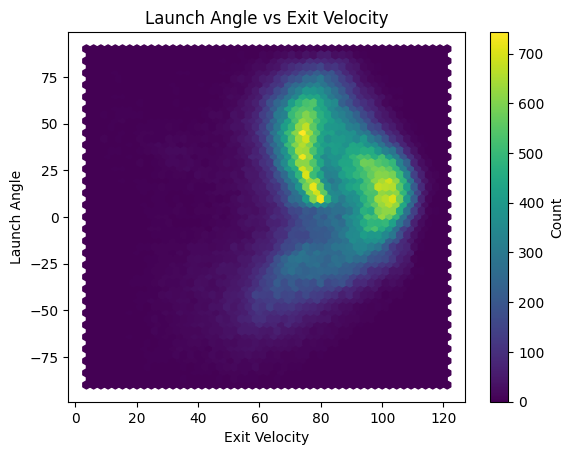

events
field_out                    72326
single                       25958
double                        8224
home_run                      5866
force_out                     3582
grounded_into_double_play     3444
sac_fly                       1205
field_error                   1062
triple                         711
sac_bunt                       425
double_play                    389
fielders_choice                374
fielders_choice_out            283
sac_fly_double_play             24
catcher_interf                  12
triple_play                      1
Name: count, dtype: int64

In [205]:
my_query = f"""
SELECT 
    launch_speed,
    launch_angle,
    events
FROM read_parquet('{data_url}')
WHERE launch_speed IS NOT NULL
  AND launch_angle IS NOT NULL
"""

df = conn.execute(my_query).fetchdf()


plt.hexbin(df["launch_speed"], df["launch_angle"], gridsize=50)
plt.xlabel("Exit Velocity")
plt.ylabel("Launch Angle")
plt.title("Launch Angle vs Exit Velocity")
plt.colorbar(label="Count")
plt.show()

df.events.value_counts()


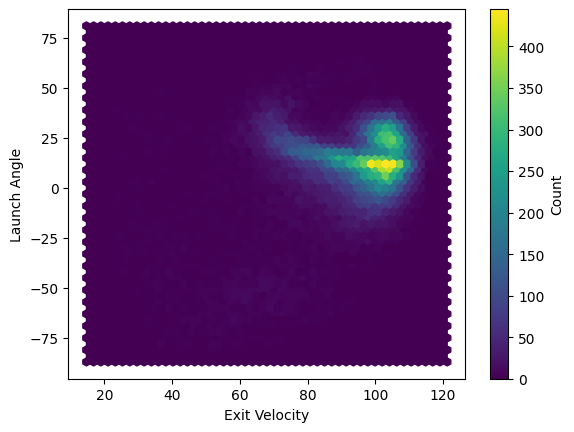

In [206]:
# Plot for just hits

df_hits = df[df["events"].isin(['single', 'double', 'triple', 'home_run'])]
plt.hexbin(df_hits["launch_speed"], df_hits["launch_angle"], gridsize=50);
plt.xlabel("Exit Velocity");
plt.ylabel("Launch Angle");
plt.colorbar(label="Count");

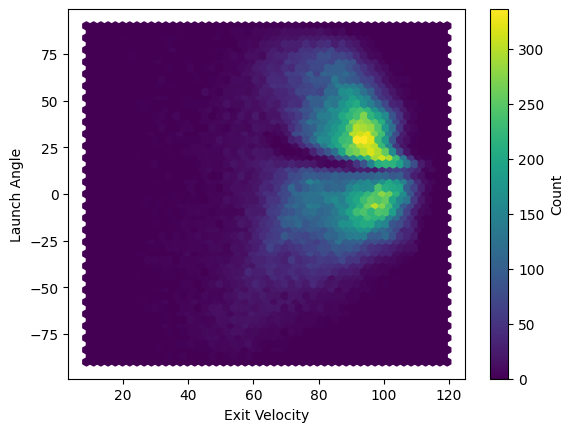

In [207]:
# Plot for field outs

df_outs = df[df["events"].isin(['field_out', 'force_out', 'grounded_into_double_play'])]
plt.hexbin(df_outs["launch_speed"], df_outs["launch_angle"], gridsize=50);
plt.xlabel("Exit Velocity");
plt.ylabel("Launch Angle");
plt.colorbar(label="Count");

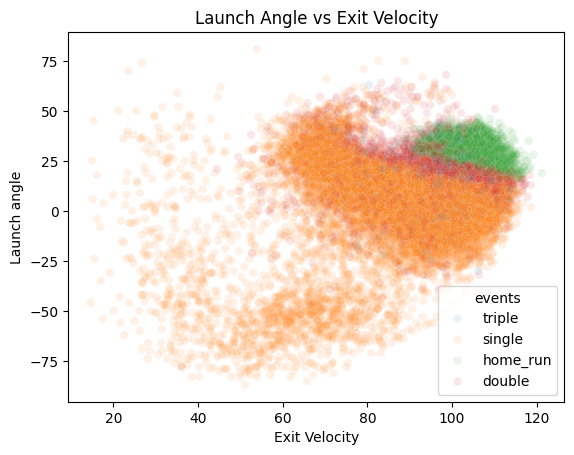

In [208]:
# Create a scatter plot colored by event type hit type (single, double, triple and home run)

sns.scatterplot(data=df_hits, x="launch_speed", y="launch_angle", alpha=0.1, hue = "events")
plt.title("Launch Angle vs Exit Velocity")
plt.xlabel("Exit Velocity")
plt.ylabel("Launch angle")
plt.show()

## 2.5: Home run distance as a function of exit velocity 

How does home run distance relate to exit velocity? Let's explore this!

**Exercise**

We can use the `hit_distance_sc` column in the Statcast data to get the distance of the batted ball from home plate in feet. By plotting this against exit velocity, we can see how the distance of home runs relates to the speed of the ball off the bat. We can use a scatter plot to visualize this relationship, with exit velocity on the x-axis and home run distance on the y-axis. This will allow us to see if there is a positive correlation between exit velocity and home run distance, which is what we would expect based on our understanding of physics and baseball.



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

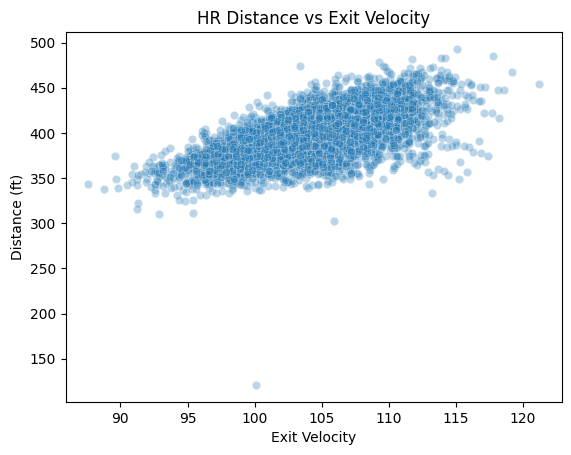

In [209]:
# Home Run Distance vs Exit Velocity

my_query = f"""
SELECT 
    launch_speed,
    hit_distance_sc
FROM read_parquet('{data_url}')
WHERE events = 'home_run'
"""

df = conn.execute(my_query).fetchdf()

sns.scatterplot(data=df, x="launch_speed", y="hit_distance_sc", alpha=0.3)
plt.title("HR Distance vs Exit Velocity")
plt.xlabel("Exit Velocity")
plt.ylabel("Distance (ft)")
plt.show()

In [210]:
%%capture

# Note: Jupyter notebooks with interactive graphics do not render well as pdfs
!quarto render class_12_answers.ipynb --cache-refresh --to pdf 
